In [1]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='train', 
                                categories=['comp.graphics',
                                            'rec.autos', 'sci.med'])

print(newsgroups['target_names'])

['comp.graphics', 'rec.autos', 'sci.med']


In [2]:
newsgroups.keys()

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [3]:
import pandas as pd
df = pd.DataFrame({'document': newsgroups['data'],
                   'category': newsgroups['target']})

df['category'] = df['category'].astype('category')
df['category'] = df['category'].cat.rename_categories(newsgroups['target_names'])

df

,document,category
0,From: bbs.mirage@tsoft.net (Jerry Lee)\nSubjec...,comp.graphics
1,From: tedebear@leland.Stanford.EDU (Theodore C...,rec.autos
2,From: welty@cabot.balltown.cma.COM (richard we...,rec.autos
3,From: mchaffee@dcl-nxt07 (Michael T Chaffee)\n...,rec.autos
4,From: zyeh@caspian.usc.edu (zhenghao yeh)\nSub...,comp.graphics
...,...,...
1767,From: madman@austin.ibm.com (Steve Heracleous)...,rec.autos
1768,From: disser@engin.umich.edu (David Disser)\nS...,comp.graphics
1769,From: pvconway@cudnvr.denver.colorado.edu\nSub...,comp.graphics
1770,From: jmilhoan@magnus.acs.ohio-state.edu (JT)\...,sci.med


In [4]:
# Clean text
df['document'] = df['document'].str.lower()
# Change carry return for a space
df['document'] = df['document'].str.replace('\n', ' ')
# Remove extra spaces
df['document'] = df['document'].str.replace(' +', ' ', regex=True)
# Removes characters that are not a word character
df['document'] = df['document'].str.replace('[^a-z ]', '', regex=True)

df

,document,category
0,from bbsmiragetsoftnet jerry lee subject cobra...,comp.graphics
1,from tedebearlelandstanfordedu theodore chen s...,rec.autos
2,from weltycabotballtowncmacom richard welty su...,rec.autos
3,from mchaffeedclnxt michael t chaffee subject ...,rec.autos
4,from zyehcaspianuscedu zhenghao yeh subject re...,comp.graphics
...,...,...
1767,from madmanaustinibmcom steve heracleous subje...,rec.autos
1768,from disserenginumichedu david disser subject ...,comp.graphics
1769,from pvconwaycudnvrdenvercoloradoedu subject t...,comp.graphics
1770,from jmilhoanmagnusacsohiostateedu jt subject ...,sci.med


In [5]:
import nltk
from nltk.corpus import stopwords

In [6]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mp15688/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def remove_stopwords(text):
    return ' '.join(w for w in text.split(' ') if w not in stop_words)

df['document'] = df['document'].apply(remove_stopwords)
df

,document,category
0,bbsmiragetsoftnet jerry lee subject cobra b v...,comp.graphics
1,tedebearlelandstanfordedu theodore chen subjec...,rec.autos
2,weltycabotballtowncmacom richard welty subject...,rec.autos
3,mchaffeedclnxt michael chaffee subject manual ...,rec.autos
4,zyehcaspianuscedu zhenghao yeh subject point w...,comp.graphics
...,...,...
1767,madmanaustinibmcom steve heracleous subject wa...,rec.autos
1768,disserenginumichedu david disser subject bitma...,comp.graphics
1769,pvconwaycudnvrdenvercoloradoedu subject tin fi...,comp.graphics
1770,jmilhoanmagnusacsohiostateedu jt subject ringi...,sci.med


In [8]:
df['document']

0       bbsmiragetsoftnet jerry lee subject cobra  b v...
1       tedebearlelandstanfordedu theodore chen subjec...
2       weltycabotballtowncmacom richard welty subject...
3       mchaffeedclnxt michael chaffee subject manual ...
4       zyehcaspianuscedu zhenghao yeh subject point w...
                              ...                        
1767    madmanaustinibmcom steve heracleous subject wa...
1768    disserenginumichedu david disser subject bitma...
1769    pvconwaycudnvrdenvercoloradoedu subject tin fi...
1770    jmilhoanmagnusacsohiostateedu jt subject ringi...
1771    davidstatcom david dodell subject hicn medical...
Name: document, Length: 1772, dtype: object

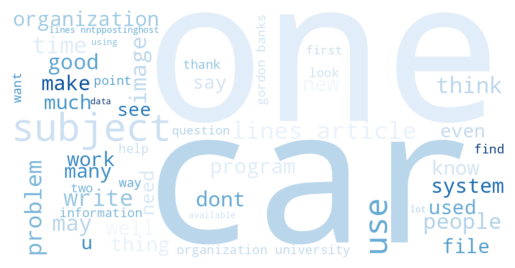

In [9]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

text = '\n'.join(list(df['document'].values))
# Create and generate a word cloud image:
wordcloud = WordCloud(width=1024, height=512, colormap="Blues", max_words=50,
                      background_color="White", contour_color="Blues").generate(text)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

wordcloud.to_file("wordcloud_all.png")

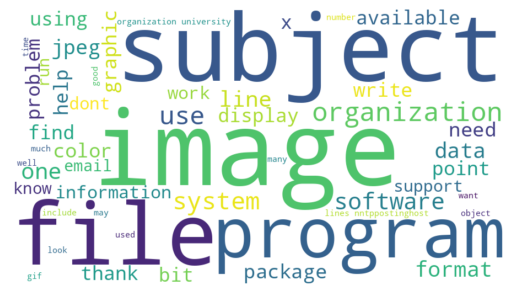

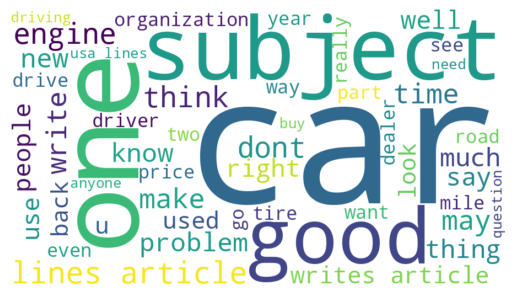

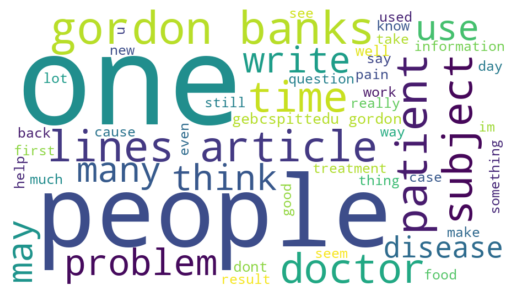

In [10]:
for category in df['category'].unique():
    text = ' '.join(list(df['document'][df['category'] == category].values))

    # Create and generate a word cloud image:
    wordcloud = WordCloud(width=900, height=500, max_words=50,
                          background_color="White", contour_color="Black").generate(text)

    # Display the generated image:
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

    wordcloud.to_file(f"wordcloud_{category}.png")

In [11]:
# Stemization
from nltk.stem import LancasterStemmer

stemmer = LancasterStemmer()

df['tokens_split'] = df['document'].apply(lambda x: [stemmer.stem(w) for w in x.split(' ')])
df['tokens'] = df['tokens_split'].apply(lambda x: ' '.join(x))



In [12]:
print(df['tokens'].head(10))
print(df['tokens_split'].head(10))

0    bbsmiragetsoftnet jerry lee subject cobr  b vi...
1    tedebearlelandstanfordedu theod chen subject b...
2    weltycabotballtowncmacom richard wel subject r...
3    mchaffeedclnxt michael chaff subject man shift...
4    zyehcaspianuscedu zhenghao yeh subject point w...
5    cfaksuxctseiuedu al sand subject froz should l...
6    cregkocrsvdelcoelectcom ron gaskin subject dum...
7    dstampepsychtorontoedu dav stamp subject fast ...
8    samsonprlhpprlphilipscouk mark samson subject ...
9    brandtcsuncedu andrew brandt subject run pathf...
Name: tokens, dtype: object
0    [bbsmiragetsoftnet, jerry, lee, subject, cobr,...
1    [tedebearlelandstanfordedu, theod, chen, subje...
2    [weltycabotballtowncmacom, richard, wel, subje...
3    [mchaffeedclnxt, michael, chaff, subject, man,...
4    [zyehcaspianuscedu, zhenghao, yeh, subject, po...
5    [cfaksuxctseiuedu, al, sand, subject, froz, sh...
6    [cregkocrsvdelcoelectcom, ron, gaskin, subject...
7    [dstampepsychtorontoedu, dav, st

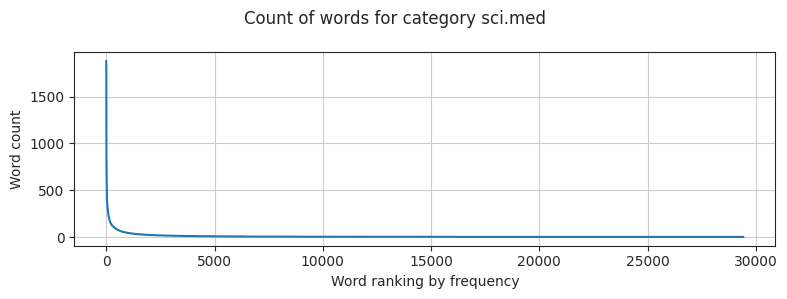

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks",{'axes.grid' : True})

from collections import Counter

word_counts = Counter(df['document'].agg('sum').split(' '))
# Remove empty tokens
word_counts = [pair for pair in word_counts.items() if pair[0] != '']
fig, ax = plt.subplots(figsize=(8, 3))
fig.suptitle(f'Count of words for category {category}')
x, y = zip(*word_counts)
ax.plot(sorted(y, reverse=True))
ax.grid(visible=True, which="both")
ax.set_ylabel('Word count')
ax.set_xlabel('Word ranking by frequency')
fig.tight_layout()
fig.savefig(f'count_all.png')

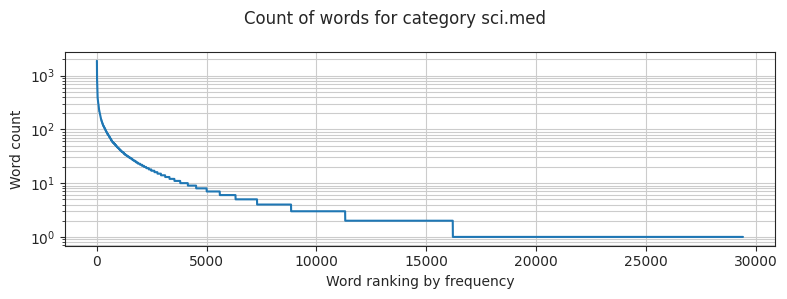

In [32]:
fig, ax = plt.subplots(figsize=(8, 3))
fig.suptitle(f'Count of words for category {category}')
x, y = zip(*word_counts)
ax.plot(sorted(y, reverse=True))
ax.grid(visible=True, which="both")
ax.set_yscale('log')
ax.grid(visible=True, which="both")
ax.set_ylabel('Word count')
ax.set_xlabel('Word ranking by frequency')
fig.tight_layout()
fig.savefig(f'count_all_logy.png')

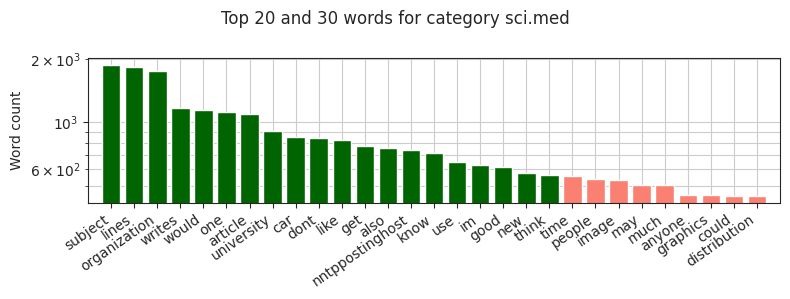

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks",{'axes.grid' : True})

from collections import Counter
top_n = 20
top_m = 30

word_counts = Counter(df['document'].agg('sum').split(' '))
# Remove empty tokens
word_counts = [pair for pair in word_counts.most_common(top_m) if pair[0] != '']
fig, ax = plt.subplots(figsize=(8, 3))
fig.suptitle(f'Top {top_n} and {top_m} words for category {category}')
x, y = zip(*word_counts)
ax.bar(x, y, color=['darkgreen' if i < top_n else 'salmon' for i in range(top_m)])
ax.set_xticks(range(len(x)), x, rotation=35, ha='right')
ax.set_xlim(-1, len(x))
ax.set_yscale('log')
ax.grid(visible=True, which="both")
ax.set_ylabel('Word count')
fig.tight_layout()
fig.savefig(f'count_{top_m}.png')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks",{'axes.grid' : True})

from collections import Counter
top_n = 20
top_m = 30

for category, df_cat in df.groupby('category'):
    word_counts = Counter(df_cat['tokens_split'].agg('sum'))
    # Remove empty tokens
    word_counts = [pair for pair in word_counts.most_common(top_m) if pair[0] != '']
    fig, ax = plt.subplots(figsize=(8, 3))
    fig.suptitle(f'Top {top_n} and {top_m} tokens for category {category}')
    x, y = zip(*word_counts)
    ax.bar(x, y, color=['darkgreen' if i < top_n else 'salmon' for i in range(top_m)])
    ax.set_xticks(range(len(x)), x, rotation=35, ha='right')
    ax.set_xlim(-1, len(x))
    ax.set_yscale('log')
    ax.grid(visible=True, which="both")
    ax.set_ylabel('Token count')
    fig.tight_layout()
    fig.savefig(f'count_{top_m}_category_{category}.png')

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(analyzer='word',
                             use_idf=True,
                             sublinear_tf=False,
                             max_features=300,
                             tokenizer=None)

X = np.array(vectorizer.fit_transform(df['tokens']).todense())

In [17]:
selected_tokens = vectorizer.get_feature_names_out()
print(f"A total of {len(selected_tokens)} have been selected")
print(f"The following is a sample sorted alfabetically\n{selected_tokens[:30]}")

A total of 300 have been selected
The following is a sample sorted alfabetically
['abl' 'act' 'ad' 'address' 'adv' 'ag' 'also' 'anim' 'anoth' 'anyon'
 'anyth' 'apply' 'apprecy' 'around' 'artic' 'ask' 'avail' 'back' 'bad'
 'bank' 'bas' 'believ' 'best' 'bet' 'big' 'bit' 'body' 'book' 'buy' 'cal']


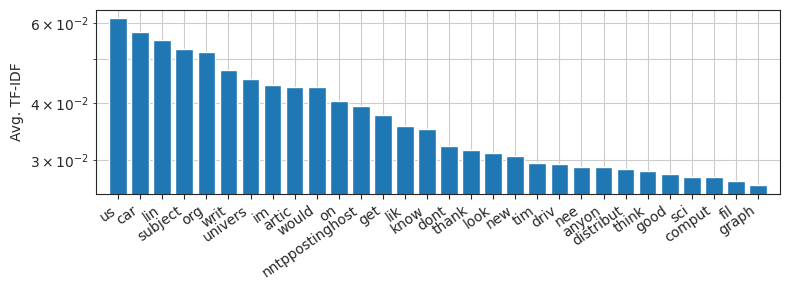

In [18]:
mean_tfidf = np.array(X.mean(axis=0)).squeeze()
sorted_idx = (-1 * mean_tfidf).argsort()[:30]

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(sorted_idx)), mean_tfidf[sorted_idx])
ax.set_xticks(range(len(sorted_idx)), np.array(selected_tokens)[sorted_idx], rotation=35, ha='right')
ax.set_xlim(-1, len(sorted_idx))
ax.set_yscale('log')
ax.grid(visible=True, which="both")
ax.set_ylabel('Avg. TF-IDF')
fig.tight_layout()
fig.savefig('tfidf_30_all')

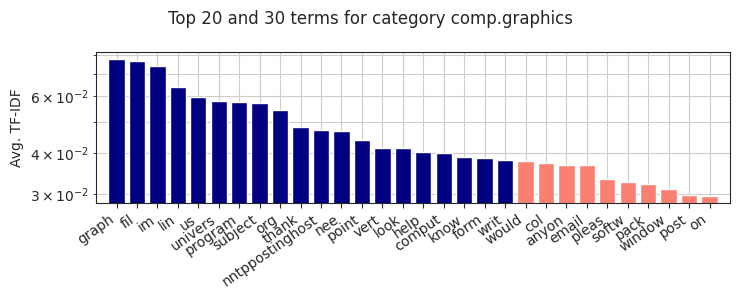

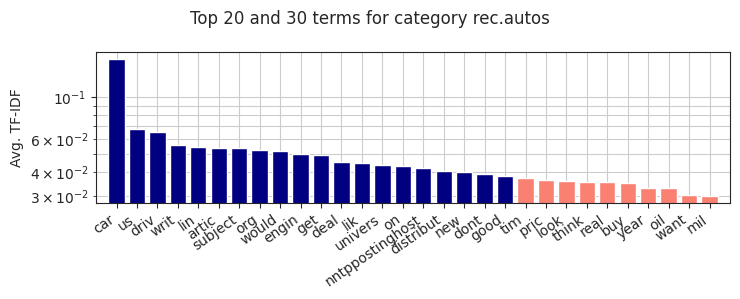

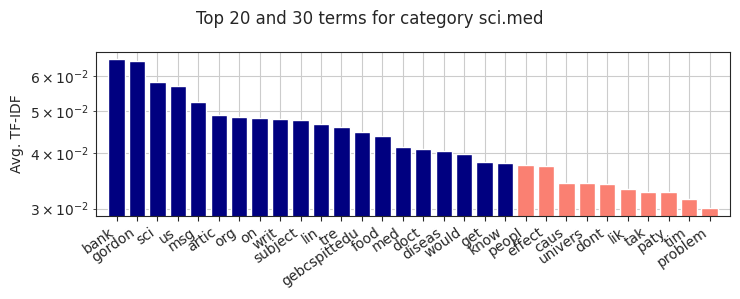

In [19]:
top_n = 20
top_m = 30

for category in df['category'].unique():
    mean_tfidf = np.array(X[df['category'] == category].mean(axis=0)).squeeze()
    sorted_idx = (-1 * mean_tfidf).argsort()[:top_m]

    fig, ax = plt.subplots(figsize=(7.5, 3))
    fig.suptitle(f'Top {top_n} and {top_m} terms for category {category}')
    ax.bar(range(len(sorted_idx)), mean_tfidf[sorted_idx], color=['navy' if i < top_n else 'salmon' for i in range(top_m)])
    ax.set_xticks(range(len(sorted_idx)), np.array(selected_tokens)[sorted_idx], rotation=35, ha='right')
    ax.set_xlim(-1, len(sorted_idx))
    ax.set_yscale('log')
    ax.grid(visible=True, which="both")
    ax.set_ylabel('Avg. TF-IDF')
    fig.tight_layout()
    fig.savefig(f'tfidf_{top_m}_category_{category}.png')

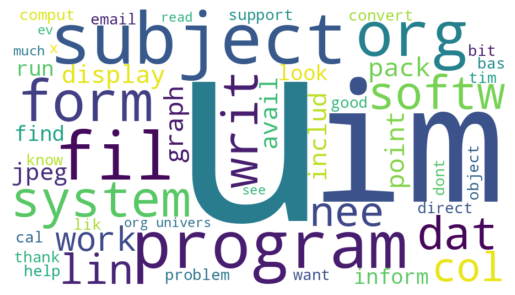

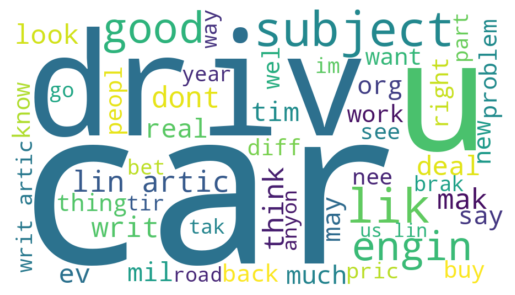

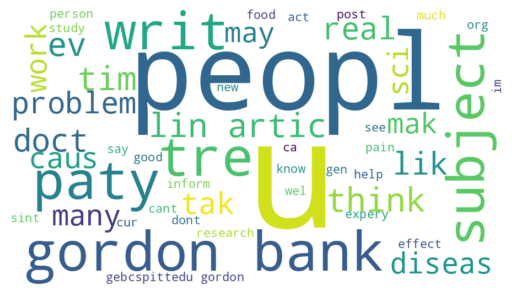

In [20]:
for category in df['category'].unique():
    text = ' '.join(list(df['tokens'][df['category'] == category].values))

    # Create and generate a word cloud image:
    wordcloud = WordCloud(width=900, height=500, max_words=50,
                          background_color="White", contour_color="Black").generate(text)

    # Display the generated image:
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

    wordcloud.to_file(f"wordcloud_tokens_{category}.png")